<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/8.%20Agentic%20AI%20Systems/9.%20%20Browser%20Automation%20%26%20Web%20Agents/8_sep_Browser_automation_Classroom.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

##AGENDA:


Today we are going to understand how we can use AI agents to interact with real websites and browsers

We will start at 9:07 pm


In [ ]:
# ===================================================================
# ONE-TIME SETUP CELL (run first, takes 2-4 minutes in Colab)
# ===================================================================

# 1. Python packages.
#    browser-use 0.1.40 requires playwright>=1.49 and pydantic>=2.10.4,
#    so we pin a COMPATIBLE playwright and let pip resolve pydantic.
#    (The old pins playwright==1.47.0 / pydantic==2.9.2 caused
#     "ResolutionImpossible" and nothing installed.)
#    langchain==0.3.18 is pinned so Colab's stale pre-installed langchain
#    matches langchain-core 0.3.x (otherwise ChatGroq -> 'module langchain
#    has no attribute verbose'). RESTART THE RUNTIME after this cell.
!pip -q install browser-use==0.1.40 langchain-groq==0.2.0 langchain==0.3.18 playwright==1.49.0 nest_asyncio==1.6.0

# 2. Chromium browser binary + OS-level libraries
!playwright install chromium
!playwright install-deps chromium > /dev/null 2>&1

# 3. Allow nested event loops (Colab already has one running)
import nest_asyncio
nest_asyncio.apply()

print("Setup complete. Playwright, browser-use, langchain-groq installed.")

Setup complete. Playwright, browser-use, langchain-groq installed.


In [ ]:
# ===================================================================
# Load GROQ_API_KEY from Colab Secrets
# ===================================================================
import os
from google.colab import userdata

try:
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
    print("GROQ_API_KEY loaded from Colab Secrets.")
except Exception as e:
    print("GROQ_API_KEY not found in Colab Secrets.")
    print("Add it via the key icon in the left sidebar, then re-run this cell.")
    print(f"Underlying error: {e}")

GROQ_API_KEY loaded from Colab Secrets.


#Section 1 :Why Agents needs browser
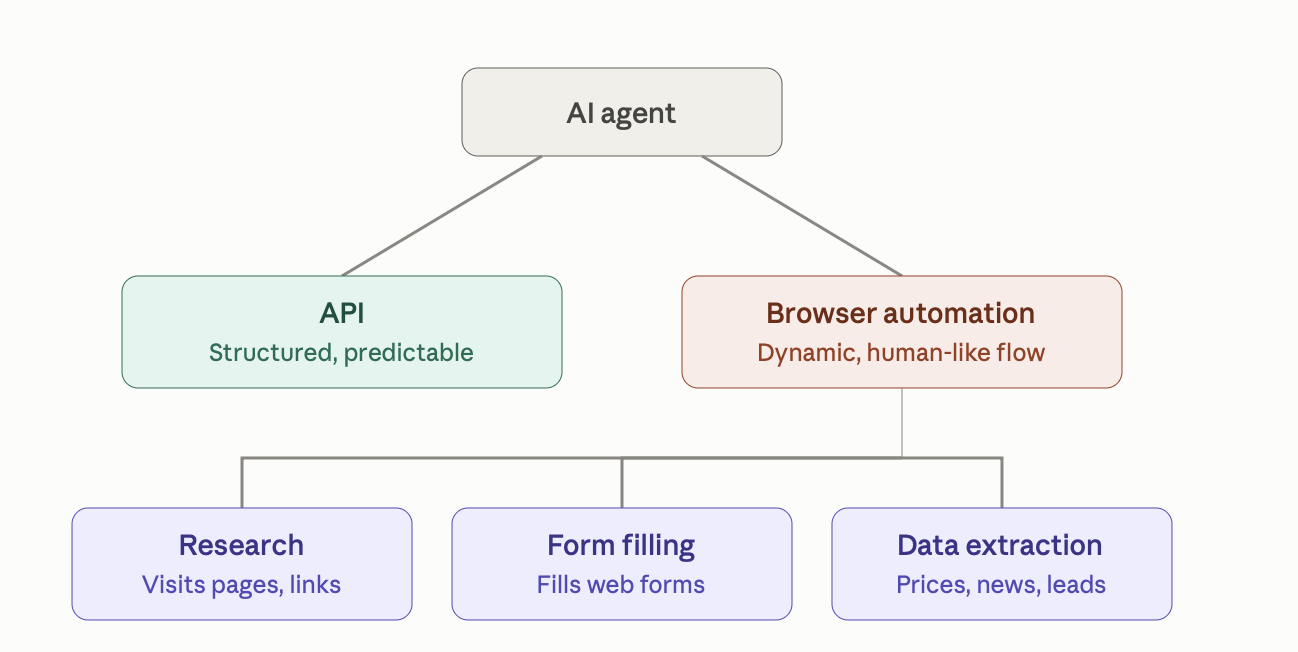

#Section 2: Playwright Basics for Agent Integration

***What is Playwright?***

Playwright is a browser automation library developed by Microsoft.
It allows us to programmatically control modern web browsers using Python.
Playwright supports:

      Chromium
      Firefox
      WebKit

For AI agents, Playwright can act as the browser-control layer.

The AI agent decides what needs to be done, while Playwright performs the actual browser interaction.

Important Features of Playwright:

1. **Auto-waiting** — waits for elements to be actionable before acting
2. **Network interception** out of the box
3. **Multiple browser contexts** in one process — cheap parallelism

![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/205/540/original/img2.png?1782202839)

In [ ]:
# Conceptual diagram — Browser → Context → Page hierarchy
print("Browser -> Context -> Page. Memorize this hierarchy.")
print()
print("Browser   = the entire Chrome process (expensive to start, start once)")
print("Context   = one incognito window (own cookies, storage, identity)")
print("Page      = one tab inside a context")

Browser -> Context -> Page. Memorize this hierarchy.

Browser   = the entire Chrome process (expensive to start, start once)
Context   = one incognito window (own cookies, storage, identity)
Page      = one tab inside a context


In [ ]:
# Simplest Playwright example - async API (Colab-friendly)
# Browser binaries were already installed in the setup cell above.
from playwright.async_api import async_playwright

async def hello_playwright():
    async with async_playwright() as p:
        # headless=True is mandatory on Colab (no display available)
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context()
        page    = await context.new_page()

        await page.goto("https://en.wikipedia.org/wiki/Transformer_(deep_learning)")
        title   = await page.title()
        heading = await page.locator("h1").inner_text()

        await browser.close()
        return title, heading

title, heading = await hello_playwright()
print(f"Page title: {title}")
print(f"H1 text:    {heading}")

Page title: Transformer (deep learning) - Wikipedia
H1 text:    Transformer (deep learning)


SECTION 3 : Priority order (most robust → most fragile):

| Strategy | Example | Stability |
|---|---|---|
| **Role-based** | `get_by_role("button", name="Add to cart")` | ✅ Best |
| **Text/Label** | `get_by_text("Forgot password?")` | ✅ Good |
| **data-testid** | `locator("[data-testid='price']")` | ✅ Good |
| **CSS class** | `locator("button.css-1xyz9q")` | ⚠️ Fragile |
| **XPath** | `locator("xpath=/html/body/div[3]/...")` | ❌ Avoid |

> **Rule for agents:** prefer role and text locators — they match how a human (and an LLM reading the accessibility tree) describes the page.


![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/205/554/original/img3.png?1782203085)

In [ ]:


# Here we’re doing a simple Playwright search demo using Wikipedia.
# We create a browser and a separate context, and then open a new page. Instead of typing into Wikipedia’s search box, we directly navigate to the search results URL. This is more reliable because the search box is a JavaScript widget and can sometimes change while we are interacting with it.
# Then we locate the search-result links and extract the first three titles. If the results list isn't available, we have a fallback that reads the page heading.
# So basically, the flow is: open browser → search Wikipedia → find results → extract the top three titles → print them.”
# Output
# For the query “browser automation software”, the code prints something like:
# Outcome: search results
# 1. Browser automation
# 2. Web browser automation
# 3. Selenium

from urllib.parse import quote_plus
from playwright.async_api import async_playwright

async def search_demo(query: str):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent=(
                "Mozilla/5.0 (X11; Linux x86_64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/126.0.0.0 Safari/537.36"
            )
        )
        page = await context.new_page()

        # fulltext=1 forces the results-list page (even when an exact-title
        # article exists), so the parsing below is deterministic.
        await page.goto(
            f"https://en.wikipedia.org/w/index.php?fulltext=1&search={quote_plus(query)}&ns0=1",
            wait_until="domcontentloaded",
        )

        results = page.locator("ul.mw-search-results .mw-search-result-heading a")
        try:
            await results.first.wait_for(timeout=10000)
            titles = await results.all_inner_texts()
            kind = "search results"
        except Exception:
            # Fallback: if no list rendered, read the page heading.
            titles = [await page.locator("h1#firstHeading").inner_text()]
            kind = "direct article"

        await browser.close()
        return kind, titles[:3]

kind, top_results = await search_demo("browser automation software")
print(f"Outcome: {kind}")
for i, r in enumerate(top_results, 1):
    print(f"{i}. {r}")

Outcome: search results
1. Headless browser
2. Test automation
3. Playwright (software)


#Section 4:Auto-Wait — Why Playwright is Agent-Friendly

When you call `page.click(...)`, Playwright first checks:
1. Element is **attached** to the DOM
2. Element is **visible**
3. Element is **stable** (not animating)
4. Element **receives events** (not covered by an overlay)
5. Element is **enabled**

Only when all five pass does the click fire — retrying up to the timeout (default 30s).

> For an LLM agent, this is huge. The model doesn't need to reason about page load timing.

**Explicit waits (when you need more control):**
```python
await page.wait_for_selector(".results", state="visible")  # ✅ preferred
await page.wait_for_url("**/dashboard")
await page.wait_for_load_state("networkidle")               # ⚠️ often wrong on modern sites
```

> ⚠️ `networkidle` is overused. Sites like Flipkart/Amazon never truly go idle due to background pings. Prefer waiting on a **specific element or URL pattern**.



### SECTION 5 : Dynamic Content and SPAs

Most modern Indian consumer sites (Flipkart, Swiggy, Zomato, Cred) are **Single Page Applications**. They load a near-empty HTML shell, then JavaScript builds the page. `requests.get(url).text` returns almost nothing.

Playwright runs a real browser, so JavaScript executes normally. But you now need to know **when the page is "done"**.

**Three patterns:**
1. Wait for a specific element you actually need ✅ **(gold standard)**
2. Intercept the underlying network/API call for clean JSON
3. Infinite scroll — scroll, wait for new items, repeat (always with a cap!)

In [ ]:
from playwright.async_api import async_playwright

async def infinite_scroll_demo():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page    = await browser.new_page()

        await page.goto("https://quotes.toscrape.com/scroll", wait_until="domcontentloaded")
        await page.wait_for_selector(".quote", timeout=10000)

        previous_count = 0
        for _ in range(8):          # ← ALWAYS set a safety cap
            await page.mouse.wheel(0, 5000)
            await page.wait_for_timeout(1200)
            current_count = await page.locator(".quote").count()
            if current_count == previous_count:
                break
            previous_count = current_count

        total = await page.locator(".quote").count()
        await browser.close()
        return total

total_quotes = await infinite_scroll_demo()
print(f"Loaded {total_quotes} quotes via infinite scroll.")

Loaded 50 quotes via infinite scroll.


###SECTION 6:  Authentication Pattern 1: `storage_state` (Production Pattern)

**The problem:** Logging in from scratch every run is slow, triggers anti-bot heuristics, and may trigger 2FA.

**The solution:** Log in once → save cookies + localStorage to a JSON file → every subsequent run loads that file.

> **Analogy:** The "Remember me on this device" checkbox. You authenticate once; your machine becomes a trusted device. `storage_state.json` is the agent's trusted-device certificate.

**On Colab (no interactive display), the flow is:**
1. Run an interactive script **locally** (`headless=False`), log in by hand, save the state file
2. Upload that file to Colab
3. Load the state file in Colab

> ⚠️ **Security:** `auth_state.json` contains session cookies. Anyone with this file can act as you. Treat it like an SSH key — never commit it, add to `.gitignore`, store encrypted in production (AWS Secrets Manager, Vault, etc.)

In [ ]:
# STEP 1 — Run this LOCALLY (not in Colab): one-time manual login
# Copy-paste this into a local Python file and run it on your laptop.

LOCAL_SCRIPT = '''
from playwright.sync_api import sync_playwright

with sync_playwright() as p:
    browser = p.chromium.launch(
        headless=False,
        channel="chrome",  # use real installed Chrome, not bundled Chromium
        args=["--disable-blink-features=AutomationControlled"],
    )
    context = browser.new_context(
        viewport={"width": 1280, "height": 800},
        user_agent=(
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        ),
    )
    page = context.new_page()
    page.goto("https://github.com/login")
    input("Log in manually in the browser, then press Enter here...")
    context.storage_state(path="github_state.json")
    browser.close()
    print("Session saved to github_state.json")
'''
print(LOCAL_SCRIPT)
print("After running locally, upload github_state.json via Colab's file pane (📁 icon).")


from playwright.sync_api import sync_playwright

with sync_playwright() as p:
    browser = p.chromium.launch(
        headless=False,
        channel="chrome",  # use real installed Chrome, not bundled Chromium
        args=["--disable-blink-features=AutomationControlled"],
    )
    context = browser.new_context(
        viewport={"width": 1280, "height": 800},
        user_agent=(
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        ),
    )
    page = context.new_page()
    page.goto("https://github.com/login")
    input("Log in manually in the browser, then press Enter here...")
    context.storage_state(path="github_state.json")
    browser.close()
    print("Session saved to github_state.json")

After running locally, upload github_state.json via Colab's file pane (📁 icon).


In [ ]:
# STEP 2 — Reuse the saved session in Colab
import os
from playwright.async_api import async_playwright

async def run_with_saved_session(target_url: str, state_path: str = "github_state.json"):
    if not os.path.exists(state_path):
        print(f"No session file at {state_path}.")
        print("Upload it via Colab's file pane (📁 icon) first.")
        return None

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        # ↓ pass storage_state here — starts already logged in
        context = await browser.new_context(storage_state=state_path)
        page    = await context.new_page()
        await page.goto(target_url)
        title = await page.title()
        await browser.close()
        return title

title = await run_with_saved_session("https://github.com/settings/profile")
print(f"Result: {title}")

No session file at github_state.json.
Upload it via Colab's file pane (📁 icon) first.
Result: None


### Section 7: Authentication Pattern 2: Programmatic Login

Use when: rotating accounts, service accounts with credentials in a secret manager, or fresh onboarding flows.

> ⚠️ Demo below uses **publicly published credentials** from a practice site (`the-internet.herokuapp.com`). In real code, pull from Colab Secrets — never hardcode passwords.

In [ ]:
# Programmatic login demo — practice site with published test credentials
# Username: tomsmith | Password: SuperSecretPassword!
from playwright.async_api import async_playwright

async def programmatic_login_demo():
    # In production: pull from Colab Secrets
    # username = userdata.get("MY_SERVICE_USERNAME")
    username = userdata.get("MY_SERVICE_USERNAME")
    password = userdata.get("MY_SERVICE_PASSWORD")

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context()
        page    = await context.new_page()

        await page.goto("https://the-internet.herokuapp.com/login")

        await page.get_by_label("Username").fill(username)
        await page.get_by_label("Password").fill(password)
        await page.get_by_role("button", name="Login").click()

        await page.wait_for_url("**/secure", timeout=10000)
        flash_message = (await page.locator("#flash").inner_text()).strip()

        # Save session for reuse — combine both patterns!
        await context.storage_state(path="practice_state.json")

        await browser.close()
        return flash_message

msg = await programmatic_login_demo()
print(f"Login result: {msg[:120]}...")
print("Session saved to practice_state.json (visible in Colab file pane 📁).")

Login result: You logged into a secure area!
×...
Session saved to practice_state.json (visible in Colab file pane 📁).


## Session will continue from here...

We will start the session at 9:08 pm




#Section 8:browser-use Library Deep Dive

### What is browser-use and why does it exist?

Playwright gives you eyes and hands. But there's a gap between `page.click('button.add-to-cart')` and "my LLM decides on its own what to click on a page it has never seen."

**browser-use** fills that gap. It's an open-source Python library that sits on top of Playwright and gives your LLM a structured way to perceive and act on web pages.

> **Analogy:** Playwright is the steering wheel and pedals. browser-use is the chauffeur who can read road signs. You give instructions in natural language; the chauffeur translates them into precise mechanical actions.

**What browser-use does for you:**
1. **Perception** — serializes the page into a representation the LLM can reason about
2. **Action space** — fixed vocabulary: click element 7, type into element 12, scroll, go back
3. **Loop** — perceive → think → act, including retries and self-correction
4. **Extensibility** — custom actions, any LangChain-compatible LLM, Pydantic output

### How the LLM "sees" a page

**Mode 1: DOM serialization with element indexing (default)**  
browser-use walks the DOM, finds all interactive elements, filters invisible ones, and produces a numbered list:
```
[1]<button>Sign in</button>
[2]<input type="email" placeholder="Email"/>
[3]<input type="password" placeholder="Password"/>
[4]<a>Forgot password?</a>
[5]<button>Continue with Google</button>
```
The LLM sees this, decides "click element 1", emits `click_element(index=1)`. Fast, token-efficient, robust.

**Mode 2: Vision (screenshot)**  
browser-use takes a screenshot, draws colored bounding boxes with index numbers, and sends it to a vision-capable LLM. More reliable for visually complex pages (Canva, Figma) but costs more tokens.

> For text-only Groq models like `openai/gpt-oss-120b`, we use **DOM-only mode** (`use_vision=False`).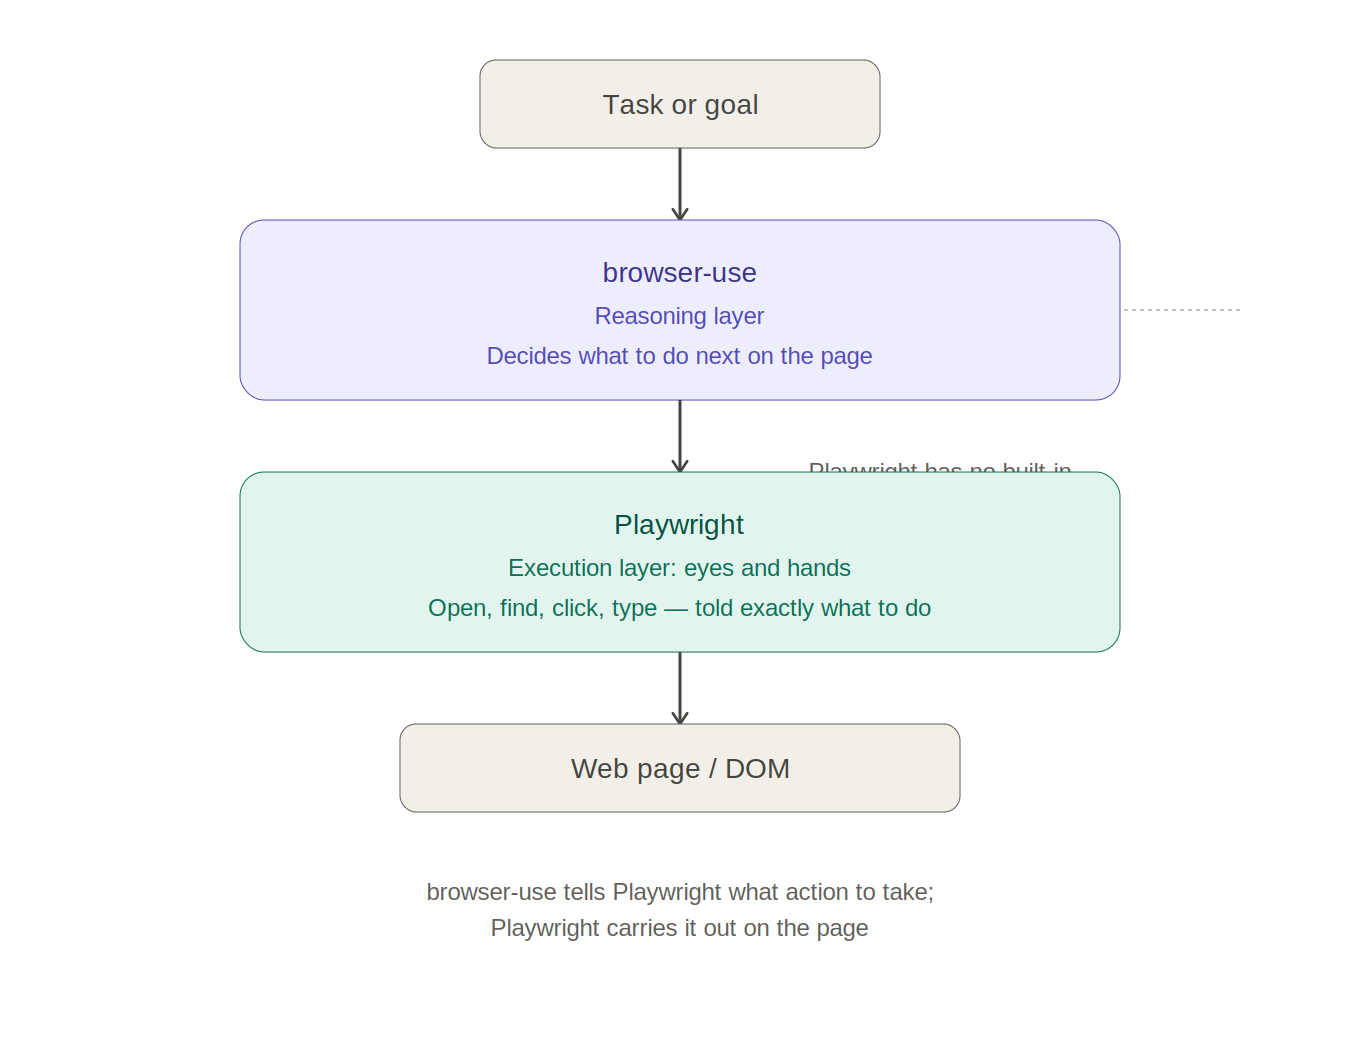

In [ ]:
# Minimal browser-use agent driven by Groq

import os

async def run_basic_agent():
    from browser_use import Agent, Browser, BrowserConfig
    from langchain_groq import ChatGroq

    # Check API key
    if not os.environ.get("GROQ_API_KEY"):
        print("GROQ_API_KEY not loaded.")
        print("Add it in Colab Secrets and re-run the secrets cell.")
        return None

    # Groq LLM
    # max_tokens=512 helps avoid the OTPM/rate-limit problem
    llm = ChatGroq(
        model="qwen/qwen3.6-27b",
        temperature=0,
        max_tokens=512,
    )

    # Colab has no GUI display, so browser must be headless
    browser = Browser(
        config=BrowserConfig(headless=True)
    )

    agent = Agent(
        task=(
            "Go to https://news.ycombinator.com, "
            "identify the first story, "
            "and return ONLY its title and point count. "
            "Keep the answer concise."
        ),
        llm=llm,
        browser=browser,
        use_vision=False,
    )

    try:
        # Keep the number of agent steps small
        history = await agent.run(max_steps=8)

        return history.final_result()

    finally:
        await browser.close()


# Run the agent ONCE
result = await run_basic_agent()

print("Final result:")
print(result)

/usr/local/lib/python3.13/dist-packages/browser_use/agent/service.py:247: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/usr/local/lib/python3.13/dist-packages/browser_use/agent/message_manager/views.py:59: LangChainBetaWarning: The function `load` is in beta. It is actively being worked on, so the API may change.
  value['message'] = load(value['message'])
/usr/local/lib/python3.13/dist-packages/browser_use/agent/message_manager/views.py:59: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  value['message'] = load(value['message'])
/usr/local/lib/python3.13/dist-packages/browse

Final result:
Title: Shopify moves back to Native from React Native
Points: 410


###Section 9:  Intermediate: Structured Output with Pydantic



In [ ]:
import os
import json
from typing import List

from pydantic import BaseModel
from groq import AsyncGroq
from playwright.async_api import async_playwright


# ============================================================
# 1. Structured output models
# ============================================================

class HNStory(BaseModel):
    title: str
    points: int
    url: str
    comments: int


class HNTop(BaseModel):
    stories: List[HNStory]


# ============================================================
# 2. Fetch Hacker News using Playwright
# ============================================================

async def get_hacker_news_page():

    async with async_playwright() as p:

        browser = await p.chromium.launch(
            headless=True
        )

        page = await browser.new_page()

        await page.goto(
            "https://news.ycombinator.com",
            wait_until="domcontentloaded"
        )

        # Wait for the Hacker News story rows
        await page.wait_for_selector(
            "tr.athing"
        )

        # Extract the first 5 stories directly from the DOM.
        stories = []

        rows = await page.locator(
            "tr.athing"
        ).all()

        for row in rows[:5]:

            title_element = row.locator(
                "span.titleline > a"
            )

            title = await title_element.inner_text()

            url = await title_element.get_attribute(
                "href"
            )

            # Hacker News puts points/comments in the
            # following <tr class="athing">.
            subtext_row = row.locator(
                "xpath=following-sibling::tr[1]"
            )

            subtext = await subtext_row.inner_text()

            stories.append({
                "title": title,
                "url": url,
                "metadata": subtext,
            })

        await browser.close()

        return stories


# ============================================================
# 3. GPT-OSS 120B structured extraction
# ============================================================

async def structure_with_gpt_oss(raw_stories):

    from groq import AsyncGroq

    client = AsyncGroq(
        api_key=os.environ["GROQ_API_KEY"]
    )

    # ========================================================
    # Groq-compatible strict JSON Schema
    # ========================================================

    schema = {
        "type": "object",
        "properties": {
            "stories": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "title": {
                            "type": "string"
                        },
                        "points": {
                            "type": "integer"
                        },
                        "url": {
                            "type": "string"
                        },
                        "comments": {
                            "type": "integer"
                        }
                    },
                    "required": [
                        "title",
                        "points",
                        "url",
                        "comments"
                    ],
                    "additionalProperties": False
                }
            }
        },
        "required": [
            "stories"
        ],
        "additionalProperties": False
    }

    prompt = f"""
Extract the top 5 Hacker News stories from the supplied data.

For every story determine:

- title
- points
- URL
- comment count

The metadata contains information such as:

"255 points by username 3 hours ago | 56 comments"

Use the supplied information only.

Do not invent information.

Return exactly 5 stories.

Here is the scraped Hacker News data:

{json.dumps(raw_stories, indent=2)}
"""

    response = await client.chat.completions.create(

        model="openai/gpt-oss-120b",

        messages=[
            {
                "role": "system",
                "content": (
                    "You are a precise web-data extraction system. "
                    "Extract the requested Hacker News information "
                    "using only the supplied data."
                ),
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],

        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "hacker_news_top_stories",
                "strict": True,
                "schema": schema,
            },
        },
    )

    content = response.choices[0].message.content

    if not content:
        raise RuntimeError(
            "GPT-OSS 120B returned an empty response."
        )

    print("\n========== GPT-OSS RAW JSON ==========\n")
    print(content)

    data = json.loads(content)

    # Validate with Pydantic
    return HNTop.model_validate(data)

# ============================================================
# 4. Complete pipeline
# ============================================================

async def run_structured_agent():

    if not os.environ.get("GROQ_API_KEY"):
        raise RuntimeError(
            "GROQ_API_KEY is not set."
        )

    print("🌐 Opening Hacker News...")

    raw_data = await get_hacker_news_page()

    print("\n========== SCRAPED DATA ==========\n")

    for item in raw_data:
        print(item)

    print("\n🤖 Sending data to GPT-OSS 120B...")

    result = await structure_with_gpt_oss(
        raw_data
    )

    return result


# ============================================================
# 5. Run
# ============================================================

parsed = await run_structured_agent()

print("\n========== TOP 5 HACKER NEWS STORIES ==========\n")

for i, story in enumerate(parsed.stories, 1):

    print(f"{i}. {story.title}")
    print(f"   Points:   {story.points}")
    print(f"   Comments: {story.comments}")
    print(f"   URL:      {story.url}")
    print()

🌐 Opening Hacker News...

========== SCRAPED DATA ==========

{'title': 'Shopify moves back to Native from React Native', 'url': 'https://shopify.engineering/back-to-native', 'metadata': '\t424 points by fnthawar2 3 hours ago | hide | 292\xa0comments'}
{'title': 'Rust Is Tier-1 Language at Microsoft', 'url': 'https://rustfoundation.org/media/guest-post-rust-is-tier-1-language-at-microsoft/', 'metadata': '\t304 points by mmastrac 3 hours ago | hide | 149\xa0comments'}
{'title': 'Cognition launches new SWE-2 model, Rivaling Fable 5.1 and GPT-Astra', 'url': 'https://cognition.com/blog/swe-2', 'metadata': '\t94 points by seelos 1 hour ago | hide | 44\xa0comments'}
{'title': 'More questions about whether researchers can trust OpenAI with unpublished math', 'url': 'https://mathstodon.xyz/@andreasthom/117240535270608201', 'metadata': '\t138 points by pred_ 4 hours ago | hide | 330\xa0comments'}
{'title': "NASA Color Trick Was Meant for Mars. Now It's Unveiling Rock Art on Earth", 'url': 'http

### Section 10: Controlling the Loop: System Prompts and Policies

The `message_context` parameter is where you encode your agent's **policies** — the equivalent of writing an SOP for your chauffeur. (In browser-use 0.1.40 this is the supported hook for injecting extra instructions; later versions add `extend_system_message`.)

In [ ]:
# ============================================================
# BBC HEADLINE EXTRACTION
# Playwright -> scrape webpage
# Groq Native API -> GPT-OSS 120B structured output
# Pydantic -> validate final result
# ============================================================

import os
import json
import asyncio
from pydantic import BaseModel


# ------------------------------------------------------------
# 1. Pydantic output models
# ------------------------------------------------------------

class BBCHeadline(BaseModel):
    headline: str
    url: str


# ------------------------------------------------------------
# 2. Scrape BBC using Playwright
# ------------------------------------------------------------

async def scrape_bbc():

    from playwright.async_api import async_playwright

    print("Opening BBC News...")

    async with async_playwright() as p:

        browser = await p.chromium.launch(
            headless=True
        )

        page = await browser.new_page()

        try:
            await page.goto(
                "https://www.bbc.com/news",
                wait_until="domcontentloaded",
                timeout=60000
            )

            # Give the page a moment to render dynamic content
            await page.wait_for_timeout(3000)

            # Collect links/headlines from the page
            links = await page.locator("a").all()

            scraped = []

            for link in links:

                try:
                    text = (await link.inner_text()).strip()
                    href = await link.get_attribute("href")

                    if not text or not href:
                        continue

                    # Ignore very short/non-headline links
                    if len(text) < 15:
                        continue

                    # Convert relative BBC URLs to absolute URLs
                    if href.startswith("/"):
                        href = "https://www.bbc.com" + href

                    scraped.append({
                        "text": text,
                        "url": href
                    })

                except Exception:
                    continue

            return scraped

        finally:
            await browser.close()


# ------------------------------------------------------------
# 3. Send scraped information to GPT-OSS 120B
# ------------------------------------------------------------

async def structure_with_gpt_oss(scraped_data):

    from groq import AsyncGroq

    client = AsyncGroq(
        api_key=os.environ["GROQ_API_KEY"]
    )

    # IMPORTANT:
    # Groq strict structured output requires
    # additionalProperties=False on every object.
    schema = {
        "type": "object",
        "properties": {
            "headline": {
                "type": "string"
            },
            "url": {
                "type": "string"
            }
        },
        "required": [
            "headline",
            "url"
        ],
        "additionalProperties": False
    }

    prompt = f"""
Find the current main/top headline from BBC News.

Use ONLY the supplied scraped BBC data.

Return:
- headline: the headline text
- url: the URL corresponding to that headline

Do not invent information.
Do not follow links.
Do not use any information other than the supplied data.

Scraped BBC data:

{json.dumps(scraped_data[:100], indent=2)}
"""

    print("\nSending data to GPT-OSS 120B...")

    response = await client.chat.completions.create(
        model="openai/gpt-oss-120b",

        messages=[
            {
                "role": "system",
                "content": (
                    "You are a precise web research assistant. "
                    "Never click advertisements. "
                    "If authentication is required, report "
                    "'auth required'. "
                    "Return only information supported by the "
                    "provided webpage data."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ],

        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "bbc_top_headline",
                "strict": True,
                "schema": schema
            }
        }
    )

    content = response.choices[0].message.content

    if not content:
        raise RuntimeError(
            "GPT-OSS 120B returned an empty response."
        )

    print("\n========== GPT-OSS RAW JSON ==========\n")
    print(content)

    # Parse JSON
    data = json.loads(content)

    # Validate using Pydantic
    return BBCHeadline.model_validate(data)


# ------------------------------------------------------------
# 4. Main pipeline
# ------------------------------------------------------------

async def run_bbc_pipeline():

    if not os.environ.get("GROQ_API_KEY"):
        print("GROQ_API_KEY not loaded.")
        return None

    # Step 1: Browser automation / scraping
    scraped_data = await scrape_bbc()

    print("\n========== SCRAPED BBC DATA ==========\n")

    for item in scraped_data[:10]:
        print(item)

    if not scraped_data:
        print("No BBC data was scraped.")
        return None

    # Step 2: GPT-OSS 120B structured extraction
    result = await structure_with_gpt_oss(scraped_data)

    return result


# ------------------------------------------------------------
# 5. Run
# ------------------------------------------------------------

bbc_result = await run_bbc_pipeline()

print("\n========== FINAL RESULT ==========\n")

if bbc_result:
    print("Headline:", bbc_result.headline)
    print("URL:", bbc_result.url)
else:
    print("No result returned.")

Opening BBC News...

========== SCRAPED BBC DATA ==========

{'text': 'Skip to content', 'url': '#bbc-main'}
{'text': 'Trump says every adult American will get $5,000 if Republicans win midterms\n\nSpeaking at a party convention, the US president gave no details on how the plan would work or where the money would come from.\n\n4 hrs ago\nUS & Canada', 'url': 'https://www.bbc.com/news/articles/c62kzr1jg0jo'}
{'text': "Can Trump really pay $5,000 to every American adult?\n\nAnalysts question if the US president's election year offer is workable, legal or affordable.\n\n40 mins ago\nUS & Canada", 'url': 'https://www.bbc.com/news/articles/c8r6vj7r8rko'}
{'text': 'Drone display recreates the Twin Towers over New York City\n\nOrganisers say each of the 2,977 drones in the display represents a victim of the 9/11 attacks.\n\n3 hrs ago\nUS & Canada', 'url': 'https://www.bbc.com/news/videos/cx2z7x57gjeo'}
{'text': "A Canadian town's famous warm welcome doesn't extend to US ambassador on 9/11 ann